In [6]:
# Librerías

import pandas as pd
import numpy as np

from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [7]:
# Carga de Dataset

df = pd.read_csv("yelp.csv")

df.head()

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


In [8]:
print(df.columns)
print(df.head())

Index(['business_id', 'date', 'review_id', 'stars', 'text', 'type', 'user_id',
       'cool', 'useful', 'funny'],
      dtype='object')
              business_id        date               review_id  stars  \
0  9yKzy9PApeiPPOUJEtnvkg  2011-01-26  fWKvX83p0-ka4JS3dc6E5A      5   
1  ZRJwVLyzEJq1VAihDhYiow  2011-07-27  IjZ33sJrzXqU-0X6U8NwyA      5   
2  6oRAC4uyJCsJl1X0WZpVSA  2012-06-14  IESLBzqUCLdSzSqm0eCSxQ      4   
3  _1QQZuf4zZOyFCvXc0o6Vg  2010-05-27  G-WvGaISbqqaMHlNnByodA      5   
4  6ozycU1RpktNG2-1BroVtw  2012-01-05  1uJFq2r5QfJG_6ExMRCaGw      5   

                                                text    type  \
0  My wife took me here on my birthday for breakf...  review   
1  I have no idea why some people give bad review...  review   
2  love the gyro plate. Rice is so good and I als...  review   
3  Rosie, Dakota, and I LOVE Chaparral Dog Park!!...  review   
4  General Manager Scott Petello is a good egg!!!...  review   

                  user_id  cool  useful  funny

In [12]:
# Selección de variables

df = df[["text", "stars"]]

# Crear variable objetivo

df["sentiment"] = df["stars"].apply(
    lambda x: 1 if x >= 4 else 0
)

print(df["sentiment"].value_counts())

df.head()

sentiment
1    6863
0    3137
Name: count, dtype: int64


/tmp/ipykernel_15393/355624803.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sentiment"] = df["stars"].apply(


,text,stars,sentiment
0,My wife took me here on my birthday for breakf...,5,1
1,I have no idea why some people give bad review...,5,1
2,love the gyro plate. Rice is so good and I als...,4,1
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",5,1
4,General Manager Scott Petello is a good egg!!!...,5,1


In [14]:
# Método basado en léxicos

positive_words = [
    "good","great","excellent","amazing",
    "love","best","nice","perfect",
    "wonderful","awesome","fantastic"
]

negative_words = [
    "bad","terrible","worst","awful",
    "poor","hate","horrible",
    "disappointing","boring","slow"
]


def lexicon_sentiment(text):

    text = str(text).lower()

    pos = sum(word in text for word in positive_words)
    neg = sum(word in text for word in negative_words)

    if pos > neg:
        return 1
    else:
        return 0


df["lexicon_prediction"] = df["text"].apply(
    lexicon_sentiment
)

df[["text","sentiment","lexicon_prediction"]].head()

/tmp/ipykernel_15393/2985179494.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["lexicon_prediction"] = df["text"].apply(


,text,sentiment,lexicon_prediction
0,My wife took me here on my birthday for breakf...,1,1
1,I have no idea why some people give bad review...,1,1
2,love the gyro plate. Rice is so good and I als...,1,1
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",1,1
4,General Manager Scott Petello is a good egg!!!...,1,1


In [19]:
# TextBlob

!pip install textblob

from textblob import TextBlob

def textblob_sentiment(text):

    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return 1
    else:
        return 0


df["textblob_prediction"] = df["text"].apply(
    textblob_sentiment
)

/tmp/ipykernel_15393/2754575397.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["textblob_prediction"] = df["text"].apply(


In [20]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (8000, 5)
Test: (2000, 5)


In [21]:
## Metricas

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("===== METODO LEXICO =====")

print("Accuracy:",
      accuracy_score(
    test_df["sentiment"],
    test_df["lexicon_prediction"]
))

print("Precision:",
      precision_score(test_df["sentiment"],
                      test_df["lexicon_prediction"]))

print("Recall:",
      recall_score(test_df["sentiment"],
                   test_df["lexicon_prediction"]))

print("F1:",
      f1_score(test_df["sentiment"],
               test_df["lexicon_prediction"]))

===== METODO LEXICO =====
Accuracy: 0.733
Precision: 0.7808661926308985
Recall: 0.8610121168923734
F1: 0.8189830508474576


In [22]:
print("===== TEXTBLOB =====")

print("Accuracy:",
      accuracy_score(test_df["sentiment"],
                     test_df["textblob_prediction"]))

print("Precision:",
      precision_score(test_df["sentiment"],
                      test_df["textblob_prediction"]))

print("Recall:",
      recall_score(test_df["sentiment"],
                   test_df["textblob_prediction"]))

print("F1:",
      f1_score(test_df["sentiment"],
               test_df["textblob_prediction"]))

===== TEXTBLOB =====
Accuracy: 0.7465
Precision: 0.7445414847161572
Recall: 0.9722024233784747
F1: 0.8432766615146832


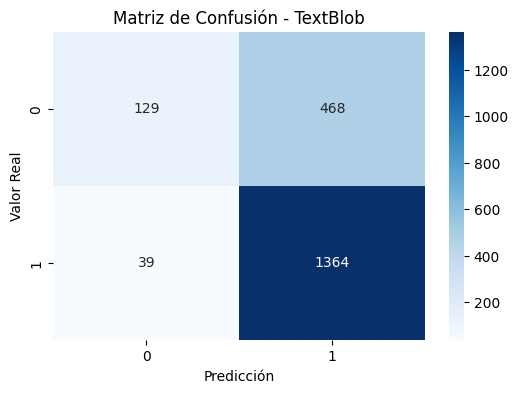

In [23]:
## Matriz de confusión

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_df["sentiment"],
    test_df["textblob_prediction"]
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - TextBlob")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()